In [3]:
import pandas as pd
import re
import requests
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# Pipeline to make votes prediction

## 1. First, let's import the necessary data

The data comes from [Dados Abertos da Camara](https://dadosabertos.camara.leg.br/swagger/api.html?tab=staticfile)

What is needed:

1. The dataset with the details of every voting session:

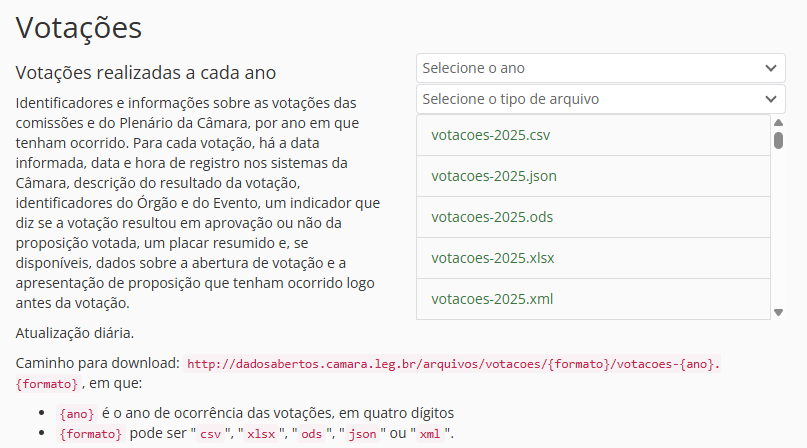

2. The dataset with the single votes from every deputy:

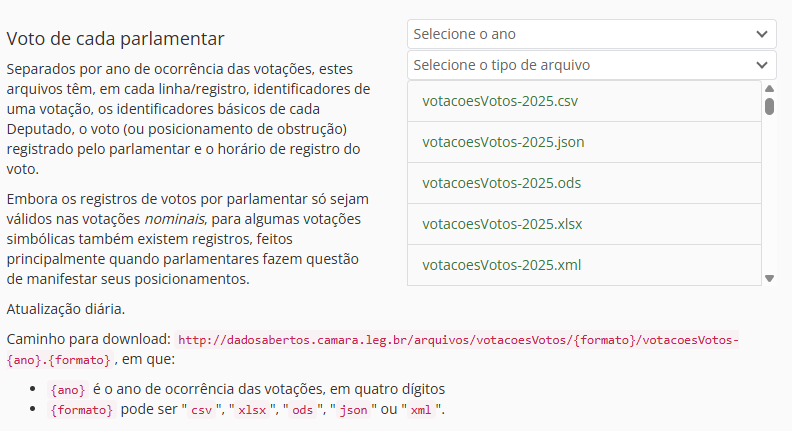

3. The dataset with propositions descriptions:

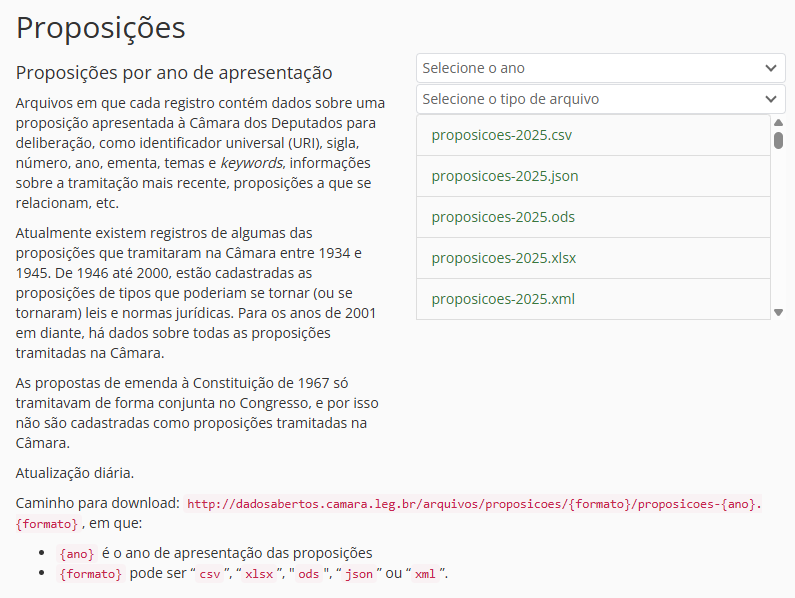




In [4]:
# Paths for voting sessions:

df_session_1 = "../data/voting/votacoes-2003.csv"

df_session_2 = "../data/voting/votacoes-2004.csv"

df_session_3 = "../data/voting/votacoes-2005.csv"

df_session_4 = "../data/voting/votacoes-2006.csv"

df_session_5 = "../data/voting/votacoes-2007.csv"

df_session_6 = "../data/voting/votacoes-2008.csv"

df_session_7 = "../data/voting/votacoes-2009.csv"

df_session_8 = "../data/voting/votacoes-2010.csv"

df_session_9 = "../data/voting/votacoes-2011.csv"

df_session_10 = "../data/voting/votacoes-2012.csv"

df_session_11 = "../data/voting/votacoes-2013.csv"

df_session_12 = "../data/voting/votacoes-2014.csv"

df_session_13 = "../data/voting/votacoes-2015.csv"

df_session_14 = "../data/voting/votacoes-2016.csv"

df_session_15 = "../data/voting/votacoes-2017.csv"

df_session_16 = "../data/voting/votacoes-2018.csv"

df_session_17 = "../data/voting/votacoes-2019.csv"

df_session_18 = "../data/voting/votacoes-2020.csv"

df_session_19 = "../data/voting/votacoes-2021.csv"

df_session_20 = "../data/voting/votacoes-2022.csv"

df_session_21 = "../data/voting/votacoes-2023.csv"

df_session_22 = "../data/voting/votacoes-2024.csv"


# df_session_3 and so on...

# ---------------------------------------------------------------

# Paths for single votes

df_votes_1 = "../data/voting/votes/votacoesVotos-2023.csv"

df_votes_2 = "../data/voting/votes/votacoesVotos-2024.csv"

# df_votes_3 and so on...

# --------------------------------------------------------------

# Paths for propositions

df_propositions_1 = "../data/propositions/proposicoes-2000.xlsx"

df_propositions_1 = "../data/propositions/proposicoes-2001.xlsx"

df_propositions_1 = "../data/propositions/proposicoes-2002.xlsx"

df_propositions_1 = "../data/propositions/proposicoes-2003.xlsx"

df_propositions_1 = "../data/propositions/proposicoes-2004.xlsx"

In [5]:
# Get all variables that match the pattern df_session_{number}
session_files = [value for key, value in globals().items() if key.startswith("df_session_")]

# Read all CSV files and concatenate into a single DataFrame
df_sessions = pd.concat([pd.read_csv(file, delimiter=';', quotechar='"') for file in session_files], ignore_index=True)

# Get all variables that match the pattern df_votes_{number}
votes_files = [value for key, value in globals().items() if key.startswith("df_votes_")]

# Read all CSV files and concatenate into a single DataFrame
df_votes = pd.concat([pd.read_csv(file, delimiter=';', quotechar='"') for file in votes_files], ignore_index=True)

# Get all variables that match the pattern df_propositions_{number}
propositions_files = [value for key, value in globals().items() if key.startswith("df_propositions_")]

# Read all CSV files and concatenate into a single DataFrame
df_propositions = pd.concat([pd.read_excel(file) for file in propositions_files], ignore_index=True)

e:\Anaconda\envs\dados_abertos\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


## 2. Data Processing

### 2.1 Filter only 'PLEN' organ

In [6]:
df_sessions['siglaOrgao'] = df_sessions['siglaOrgao'].astype(str).str.strip().str.upper()

df_sessions_PLEN = df_sessions[df_sessions['siglaOrgao'] == 'PLEN'].copy()

PLEN_IDs = df_sessions_PLEN['id'].unique()

df_votes_PLEN = df_votes[df_votes['idVotacao'].isin(PLEN_IDs)].copy()

### 2.2 Feature Selection

In [7]:
df_votes_PLEN

,idVotacao,uriVotacao,dataHoraVoto,voto,deputado_id,deputado_uri,deputado_nome,deputado_siglaPartido,deputado_uriPartido,deputado_siglaUf,deputado_idLegislatura,deputado_urlFoto
0,1197773-90,https://dadosabertos.camara.leg.br/api/v2/vota...,2023-08-09T19:27:16,Sim,220714,https://dadosabertos.camara.leg.br/api/v2/depu...,Adail Filho,REPUBLICANOS,https://dadosabertos.camara.leg.br/api/v2/part...,AM,57,https://www.camara.leg.br/internet/deputado/ba...
1,1197773-90,https://dadosabertos.camara.leg.br/api/v2/vota...,2023-08-09T19:28:56,Não,221328,https://dadosabertos.camara.leg.br/api/v2/depu...,Adilson Barroso,PL,https://dadosabertos.camara.leg.br/api/v2/part...,SP,57,https://www.camara.leg.br/internet/deputado/ba...
2,1197773-90,https://dadosabertos.camara.leg.br/api/v2/vota...,2023-08-09T19:30:35,Sim,204560,https://dadosabertos.camara.leg.br/api/v2/depu...,Adolfo Viana,PSDB,https://dadosabertos.camara.leg.br/api/v2/part...,BA,57,https://www.camara.leg.br/internet/deputado/ba...
3,1197773-90,https://dadosabertos.camara.leg.br/api/v2/vota...,2023-08-09T19:26:58,Não,204528,https://dadosabertos.camara.leg.br/api/v2/depu...,Adriana Ventura,NOVO,https://dadosabertos.camara.leg.br/api/v2/part...,SP,57,https://www.camara.leg.br/internet/deputado/ba...
4,1197773-90,https://dadosabertos.camara.leg.br/api/v2/vota...,2023-08-09T19:28:19,Sim,121948,https://dadosabertos.camara.leg.br/api/v2/depu...,Adriano do Baldy,PP,https://dadosabertos.camara.leg.br/api/v2/part...,GO,57,https://www.camara.leg.br/internet/deputado/ba...
...,...,...,...,...,...,...,...,...,...,...,...,...
244980,565397-185,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-10-16T19:58:10,Sim,220536,https://dadosabertos.camara.leg.br/api/v2/depu...,Zé Haroldo Cathedral,PSD,https://dadosabertos.camara.leg.br/api/v2/part...,RR,57,https://www.camara.leg.br/internet/deputado/ba...
244981,565397-185,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-10-16T20:00:02,Não,160632,https://dadosabertos.camara.leg.br/api/v2/depu...,Zé Silva,SOLIDARIEDADE,https://dadosabertos.camara.leg.br/api/v2/part...,MG,57,https://www.camara.leg.br/internet/deputado/ba...
244982,565397-185,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-10-16T19:59:56,Não,204517,https://dadosabertos.camara.leg.br/api/v2/depu...,Zé Vitor,PL,https://dadosabertos.camara.leg.br/api/v2/part...,MG,57,https://www.camara.leg.br/internet/deputado/ba...
244983,565397-185,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-10-16T19:59:29,Não,220592,https://dadosabertos.camara.leg.br/api/v2/depu...,Zezinho Barbary,PP,https://dadosabertos.camara.leg.br/api/v2/part...,AC,57,https://www.camara.leg.br/internet/deputado/ba...


In [8]:
df_FEATURES = df_votes_PLEN.drop(columns=['uriVotacao', 'dataHoraVoto', 'deputado_uri', 'deputado_nome', 'deputado_siglaPartido', 'deputado_uriPartido', 'deputado_siglaUf', 'deputado_idLegislatura', 'deputado_urlFoto'])
df_FEATURES

,idVotacao,voto,deputado_id
0,1197773-90,Sim,220714
1,1197773-90,Não,221328
2,1197773-90,Sim,204560
3,1197773-90,Não,204528
4,1197773-90,Sim,121948
...,...,...,...
244980,565397-185,Sim,220536
244981,565397-185,Não,160632
244982,565397-185,Não,204517
244983,565397-185,Não,220592


In [9]:
df_sessions_PLEN

,id,uri,data,dataHoraRegistro,idOrgao,uriOrgao,siglaOrgao,idEvento,uriEvento,aprovacao,votosSim,votosNao,votosOutros,descricao,ultimaAberturaVotacao_dataHoraRegistro,ultimaAberturaVotacao_descricao,ultimaApresentacaoProposicao_dataHoraRegistro,ultimaApresentacaoProposicao_descricao,ultimaApresentacaoProposicao_idProposicao,ultimaApresentacaoProposicao_uriProposicao
1,96076-49,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-02-19,NaN,180,https://dadosabertos.camara.leg.br/api/v2/orga...,PLEN,3282,https://dadosabertos.camara.leg.br/api/v2/even...,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,NaN,Votação da Redação Final.,NaN,"Parecer Proferido em Plenário, Dep. Luiz Eduar...",104848,https://dadosabertos.camara.leg.br/api/v2/prop...
2,98922-29,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-02-19,NaN,180,https://dadosabertos.camara.leg.br/api/v2/orga...,PLEN,3282,https://dadosabertos.camara.leg.br/api/v2/even...,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,NaN,Votação da Redação Final,NaN,"Parecer Proferido em Plenário, Dep. Ronaldo Ca...",104779,https://dadosabertos.camara.leg.br/api/v2/prop...
3,102277-6,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-02-19,NaN,180,https://dadosabertos.camara.leg.br/api/v2/orga...,PLEN,0,NaN,1.0,0,0,0,Aprovado requerimento n. 264/2002 de Líderes q...,NaN,NaN,2011-01-20T16:13:25,Apresentação do Requerimento pelo Deputado Wal...,104615,https://dadosabertos.camara.leg.br/api/v2/prop...
4,103255-3,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-02-19,NaN,180,https://dadosabertos.camara.leg.br/api/v2/orga...,PLEN,3282,https://dadosabertos.camara.leg.br/api/v2/even...,1.0,0,0,0,Aprovado o Requerimento,NaN,NaN,NaN,Apresentação da Urgência (Art. 155 do RICD) pe...,0,NaN
5,96076-46,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-02-19,NaN,180,https://dadosabertos.camara.leg.br/api/v2/orga...,PLEN,3282,https://dadosabertos.camara.leg.br/api/v2/even...,1.0,0,0,0,Aprovado o Substitutivo oferecido pelo Relator...,NaN,Votação em turno único.,NaN,"Parecer Proferido em Plenário, Dep. Luiz Eduar...",104848,https://dadosabertos.camara.leg.br/api/v2/prop...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155016,2473375-78,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-19,2024-12-19T21:05:40,180,https://dadosabertos.camara.leg.br/api/v2/orga...,PLEN,75369,https://dadosabertos.camara.leg.br/api/v2/even...,NaN,277,174,2,Mantido o texto. Sim: 277; Não: 174; Abstenção...,2024-12-19T20:52:40,Votação do DTQ 11 (Fdr PSOL-REDE): Destaque pa...,2024-12-19T20:29:41,Parecer às Emendas de Plenário proferido pelo ...,2481685,https://dadosabertos.camara.leg.br/api/v2/prop...
155017,2473375-80,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-19,2024-12-19T21:06:10,180,https://dadosabertos.camara.leg.br/api/v2/orga...,PLEN,75369,https://dadosabertos.camara.leg.br/api/v2/even...,1.0,0,0,0,Aprovada a Redação Final assinada pelo relator...,2024-12-19T21:05:55,Votação da Redação Final.,2024-12-19T20:29:41,Parecer às Emendas de Plenário proferido pelo ...,2481685,https://dadosabertos.camara.leg.br/api/v2/prop...
155018,2460010-35,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-19,2024-12-19T21:14:05,180,https://dadosabertos.camara.leg.br/api/v2/orga...,PLEN,75369,https://dadosabertos.camara.leg.br/api/v2/even...,0.0,82,193,1,Rejeitado o Requerimento. Sim: 82; Não: 193; T...,NaN,NaN,NaN,NaN,0,NaN
155019,2460010-43,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-19,2024-12-19T21:31:53,180,https://dadosabertos.camara.leg.br/api/v2/orga...,PLEN,75369,https://dadosabertos.camara.leg.br/api/v2/even...,1.0,340,117,2,"Aprovado o Projeto de Lei nº 3.802, de 2024. S...",2024-12-19T21:20:42,Votação em turno único.,2024-12-19T21:15:43,"Parecer proferido em Plenário pelo Relator, De...",2481698,https://dadosabertos.camara.leg.br/api/v2/prop...


In [10]:
def parse_emenda(text: str):
    """
    Checks if the text contains the word 'emenda' (case-insensitive).
    If yes, tries to find a number right after it using a regex.
    Returns (type, number):
        - ("Emenda", <num>) if 'emenda' is found and there's a number
        - ("Emenda", None) if 'emenda' is found but no number is found
        - (None, None) otherwise (if 'emenda' is not found)
    """
    text_lower = str(text).lower()
    if "emenda" in text_lower:
        pattern = re.compile(r'(?i)emenda.*?(\d+)')
        match = pattern.search(text_lower)
        if match:
            return "Emenda", match.group(1)
        else:
            return "Emenda", None
    return None, None

def extract_emenda_info(row):
    """
    1) Check if row['descricao'] contains 'emenda'.
    2) If it doesn't contain 'emenda', return (None, None).
    3) If it does contain 'emenda', attempt to find the number in 'descricao'.
    4) If no number is found in 'descricao', attempt to find it in 
       'ultimaApresentacaoProposicao_descricao'.
    """
    # Step 1 & 2: parse 'descricao' first
    t_desc, num_desc = parse_emenda(row['descricao'])
    
    # If there's no 'emenda' in 'descricao', we stop here
    if t_desc is None:
        return None, None
    
    # If we found a number in 'descricao', return it
    if num_desc is not None:
        return t_desc, num_desc
    
    # If 'emenda' was found but no number in 'descricao', 
    # check 'ultimaApresentacaoProposicao_descricao'
    _, num_ultima = parse_emenda(row['ultimaApresentacaoProposicao_descricao'])
    
    # We already know it's "Emenda" (from descricao), so just pass it along
    return "Emenda", num_ultima

In [11]:
# Create the new dataframe with the desired columns
df_sessions_selected = df_sessions_PLEN[['id', 'descricao', 'aprovacao', 'data', 'ultimaApresentacaoProposicao_idProposicao', 'ultimaApresentacaoProposicao_descricao']].copy()

# Apply the function to each row
df_sessions_selected['Type'], df_sessions_selected['E_Number'] = zip(
    *df_sessions_selected.apply(extract_emenda_info, axis=1)
)

In [12]:
df_sessions_selected

,id,descricao,aprovacao,data,ultimaApresentacaoProposicao_idProposicao,ultimaApresentacaoProposicao_descricao,Type,E_Number
1,96076-49,Aprovada a Redação Final oferecida pelo Relato...,1.0,2003-02-19,104848,"Parecer Proferido em Plenário, Dep. Luiz Eduar...",None,None
2,98922-29,Aprovada a Redação Final oferecida pelo Relato...,1.0,2003-02-19,104779,"Parecer Proferido em Plenário, Dep. Ronaldo Ca...",None,None
3,102277-6,Aprovado requerimento n. 264/2002 de Líderes q...,1.0,2003-02-19,104615,Apresentação do Requerimento pelo Deputado Wal...,None,None
4,103255-3,Aprovado o Requerimento,1.0,2003-02-19,0,Apresentação da Urgência (Art. 155 do RICD) pe...,None,None
5,96076-46,Aprovado o Substitutivo oferecido pelo Relator...,1.0,2003-02-19,104848,"Parecer Proferido em Plenário, Dep. Luiz Eduar...",None,None
...,...,...,...,...,...,...,...,...
155016,2473375-78,Mantido o texto. Sim: 277; Não: 174; Abstenção...,NaN,2024-12-19,2481685,Parecer às Emendas de Plenário proferido pelo ...,None,None
155017,2473375-80,Aprovada a Redação Final assinada pelo relator...,1.0,2024-12-19,2481685,Parecer às Emendas de Plenário proferido pelo ...,None,None
155018,2460010-35,Rejeitado o Requerimento. Sim: 82; Não: 193; T...,0.0,2024-12-19,0,NaN,None,None
155019,2460010-43,"Aprovado o Projeto de Lei nº 3.802, de 2024. S...",1.0,2024-12-19,2481698,"Parecer proferido em Plenário pelo Relator, De...",None,None


In [13]:
df_sessions_emenda = df_sessions_selected[
    (df_sessions_selected['Type'] == 'Emenda') & 
    (df_sessions_selected['E_Number'].notna())
]

df_sessions_emenda

,id,descricao,aprovacao,data,ultimaApresentacaoProposicao_idProposicao,ultimaApresentacaoProposicao_descricao,Type,E_Number
207,102569-61,"Aprovada a Emenda de Redação de Srs. Líderes, ...",1.0,2003-03-18,106259,"Leitura do Parecer pelo Relator, Dep. Gervásio...",Emenda,11
372,18480-58,Aprovado o Requerimento do Sr. Dep. Henrique F...,1.0,2003-03-20,0,NaN,Emenda,6
373,18480-61,"Aprovada a Emenda Substitutiva Global nº 6, co...",1.0,2003-03-20,0,NaN,Emenda,6
589,31767-67,"Aprovadas as Emendas de Plenário de nºs. 7, 1...",1.0,2003-04-01,109953,"Parecer Proferido em Plenário, Dep. Ibrahim Ab...",Emenda,7
590,31767-68,Rejeitadas as Emendas de Plenário de nºs. 1 a ...,0.0,2003-04-01,109953,"Parecer Proferido em Plenário, Dep. Ibrahim Ab...",Emenda,1
...,...,...,...,...,...,...,...,...
154982,2269745-144,Aprovadas as Emendas do Senado Federal ao Proj...,1.0,2024-12-18,2481147,Parecer às Emendas do Senado Federal proferido...,Emenda,327
154983,2269745-146,Rejeitados a Emenda do Senado Federal nº 3; o ...,0.0,2024-12-18,2481147,Parecer às Emendas do Senado Federal proferido...,Emenda,3
154989,347421-200,"Aprovada, em primeiro turno, a Emenda Aglutina...",1.0,2024-12-19,2025915,Apresentação do Requerimento de Inclusão na Or...,Emenda,31
155011,347421-221,"Aprovada, em segundo turno, a Proposta de Emen...",1.0,2024-12-19,2025915,Apresentação do Requerimento de Inclusão na Or...,Emenda,31


In [14]:
def fetch_pl_number_and_year(votacao_id: str):
    """
    Given a string votacao_id (e.g. '18480-61'),
    this function calls the Câmara API and returns
    the (numero, ano) tuple extracted from the JSON response.
    Returns (None, None) if something goes wrong or if data is unavailable.
    """
    print(f"  -> Fetching data for: {votacao_id}")
    url = f"https://dadosabertos.camara.leg.br/api/v2/votacoes/{votacao_id}"
    
    try:
        # Ask explicitly for JSON (though it's the default)
        resp = requests.get(url, headers={'Accept': 'application/json'})
        resp.raise_for_status()  # Raises for 4xx/5xx errors
        print(f"     Response OK (status_code={resp.status_code}).")
    except (requests.RequestException, ValueError) as ex:
        print(f"     ERROR: Problem fetching data for '{votacao_id}': {ex}")
        return None, None

    # Parse JSON
    try:
        data = resp.json()
    except ValueError as ve:
        print(f"     ERROR: Response not valid JSON for '{votacao_id}': {ve}")
        return None, None

    dados = data.get("dados", {})
    prop_afetadas = dados.get("proposicoesAfetadas", [])

    if prop_afetadas and isinstance(prop_afetadas, list):
        # We’ll assume the first item is the relevant one
        first_prop = prop_afetadas[0]
        numero = first_prop.get("numero")
        ano = first_prop.get("ano")
        print(f"     Found 'numero': {numero}, 'ano': {ano}")
        return numero, ano
    else:
        print(f"     WARNING: 'proposicoesAfetadas' is empty or not found for '{votacao_id}'.")
        return None, None

In [15]:
df_sessions_emenda['PL_number'] = None
df_sessions_emenda['PL_year'] = None

print("Starting to process rows...\n")
for idx, row in df_sessions_emenda.iterrows():
    votacao_id = row['id']
    print(f"Processing row {idx} with votacao_id: {votacao_id}")
    pl_num, pl_ano = fetch_pl_number_and_year(votacao_id)
    
    # Update the DataFrame
    df_sessions_emenda.at[idx, 'PL_number'] = pl_num
    df_sessions_emenda.at[idx, 'PL_year'] = pl_ano
    
    print(f"  -> Updated row {idx} with PL_number={pl_num}, PL_year={pl_ano}\n")

print("Finished processing all rows!")

C:\Users\Pedro Natanael\AppData\Local\Temp\ipykernel_27264\2659721224.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sessions_emenda['PL_number'] = None
C:\Users\Pedro Natanael\AppData\Local\Temp\ipykernel_27264\2659721224.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sessions_emenda['PL_year'] = None


Starting to process rows...

Processing row 207 with votacao_id: 102569-61
  -> Fetching data for: 102569-61
     Response OK (status_code=200).
     Found 'numero': 79, 'ano': 2002
  -> Updated row 207 with PL_number=79, PL_year=2002

Processing row 372 with votacao_id: 18480-58
  -> Fetching data for: 18480-58
     Response OK (status_code=200).
     Found 'numero': 2681, 'ano': 1996
  -> Updated row 372 with PL_number=2681, PL_year=1996

Processing row 373 with votacao_id: 18480-61
  -> Fetching data for: 18480-61
     Response OK (status_code=200).
     Found 'numero': 2681, 'ano': 1996
  -> Updated row 373 with PL_number=2681, PL_year=1996

Processing row 589 with votacao_id: 31767-67
  -> Fetching data for: 31767-67
     Response OK (status_code=200).
     Found 'numero': 5073, 'ano': 2001
  -> Updated row 589 with PL_number=5073, PL_year=2001

Processing row 590 with votacao_id: 31767-68
  -> Fetching data for: 31767-68
     Response OK (status_code=200).
     Found 'numero': 50

In [16]:
df_sessions_emenda

,id,descricao,aprovacao,data,ultimaApresentacaoProposicao_idProposicao,ultimaApresentacaoProposicao_descricao,Type,E_Number,PL_number,PL_year
207,102569-61,"Aprovada a Emenda de Redação de Srs. Líderes, ...",1.0,2003-03-18,106259,"Leitura do Parecer pelo Relator, Dep. Gervásio...",Emenda,11,79,2002
372,18480-58,Aprovado o Requerimento do Sr. Dep. Henrique F...,1.0,2003-03-20,0,NaN,Emenda,6,2681,1996
373,18480-61,"Aprovada a Emenda Substitutiva Global nº 6, co...",1.0,2003-03-20,0,NaN,Emenda,6,2681,1996
589,31767-67,"Aprovadas as Emendas de Plenário de nºs. 7, 1...",1.0,2003-04-01,109953,"Parecer Proferido em Plenário, Dep. Ibrahim Ab...",Emenda,7,5073,2001
590,31767-68,Rejeitadas as Emendas de Plenário de nºs. 1 a ...,0.0,2003-04-01,109953,"Parecer Proferido em Plenário, Dep. Ibrahim Ab...",Emenda,1,5073,2001
...,...,...,...,...,...,...,...,...,...,...
154982,2269745-144,Aprovadas as Emendas do Senado Federal ao Proj...,1.0,2024-12-18,2481147,Parecer às Emendas do Senado Federal proferido...,Emenda,327,327,2021
154983,2269745-146,Rejeitados a Emenda do Senado Federal nº 3; o ...,0.0,2024-12-18,2481147,Parecer às Emendas do Senado Federal proferido...,Emenda,3,327,2021
154989,347421-200,"Aprovada, em primeiro turno, a Emenda Aglutina...",1.0,2024-12-19,2025915,Apresentação do Requerimento de Inclusão na Or...,Emenda,31,31,2007
155011,347421-221,"Aprovada, em segundo turno, a Proposta de Emen...",1.0,2024-12-19,2025915,Apresentação do Requerimento de Inclusão na Or...,Emenda,31,31,2007


In [17]:
def fetch_materia_code(pl_number, pl_year):
    """
    Given a PL_number (pl_number) and PL_year (pl_year), returns the <CodigoMateria> text 
    from the Senate's "pl" or "pls" endpoint. 
    
    Order of attempts:
      1) https://legis.senado.leg.br/dadosabertos/materia/pl/{pl_number}/{pl_year}
      2) https://legis.senado.leg.br/dadosabertos/materia/pls/{pl_number}/{pl_year}
    
    Returns:
        str: The CodigoMateria text if found, otherwise None.
    """
    def try_fetch(pl_type, pl_num, pl_yr):
        """Attempt to fetch CodigoMateria from the given 'pl_type' ('pl' or 'pls')."""
        url = f"https://legis.senado.leg.br/dadosabertos/materia/{pl_type}/{pl_num}/{pl_yr}"
        print(f"  -> Fetching materia from: {url}")
        
        try:
            resp = requests.get(url, headers={'Accept': 'application/xml'})
            resp.raise_for_status()  # raises an error if 4xx/5xx
        except requests.RequestException as ex:
            print(f"     ERROR: Could not fetch '{url}' due to: {ex}")
            return None
        
        # Parse the XML
        try:
            root = ET.fromstring(resp.content)
        except ET.ParseError as ex:
            print(f"     ERROR: Unable to parse XML from '{url}': {ex}")
            return None
        
        # The XML structure:
        # <DetalheMateria>
        #   <Materia>
        #     <IdentificacaoMateria>
        #       <CodigoMateria>145886</CodigoMateria>
        #       ...
        #     </IdentificacaoMateria>
        #   </Materia>
        # </DetalheMateria>
        codigo_materia_elem = root.find(".//Materia/IdentificacaoMateria/CodigoMateria")
        if codigo_materia_elem is not None and codigo_materia_elem.text:
            print(f"     Found CodigoMateria: {codigo_materia_elem.text}")
            return codigo_materia_elem.text
        
        print(f"     WARNING: No <CodigoMateria> found in XML for '{url}'")
        return None

    # 1st attempt: pl
    codigo_materia = try_fetch('pl', pl_number, pl_year)
    if codigo_materia:
        return codigo_materia
    
    # 2nd attempt: pls (only if the first returned None)
    return try_fetch('pls', pl_number, pl_year)

In [18]:
df_sessions_emenda['materia'] = None  # Initialize with None

for idx, row in df_sessions_emenda.iterrows():
    pl_num = row['PL_number']
    pl_year = row['PL_year']
    
    # Make sure we have valid PL_number and PL_year before calling the API
    if pd.notna(pl_num) and pd.notna(pl_year):
        materia_code = fetch_materia_code(pl_num, pl_year)
        df_sessions_emenda.at[idx, 'materia'] = materia_code
    else:
        # If pl_num or pl_year is NaN/None, skip
        df_sessions_emenda.at[idx, 'materia'] = None

# Now df_sessions_emenda has a new column 'materia' with the CodigoMateria from the API

C:\Users\Pedro Natanael\AppData\Local\Temp\ipykernel_27264\1130258008.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sessions_emenda['materia'] = None  # Initialize with None


  -> Fetching materia from: https://legis.senado.leg.br/dadosabertos/materia/pl/79/2002
  -> Fetching materia from: https://legis.senado.leg.br/dadosabertos/materia/pls/79/2002
     Found CodigoMateria: 49877
  -> Fetching materia from: https://legis.senado.leg.br/dadosabertos/materia/pl/2681/1996
  -> Fetching materia from: https://legis.senado.leg.br/dadosabertos/materia/pls/2681/1996
  -> Fetching materia from: https://legis.senado.leg.br/dadosabertos/materia/pl/2681/1996
  -> Fetching materia from: https://legis.senado.leg.br/dadosabertos/materia/pls/2681/1996
  -> Fetching materia from: https://legis.senado.leg.br/dadosabertos/materia/pl/5073/2001
  -> Fetching materia from: https://legis.senado.leg.br/dadosabertos/materia/pls/5073/2001
  -> Fetching materia from: https://legis.senado.leg.br/dadosabertos/materia/pl/5073/2001
  -> Fetching materia from: https://legis.senado.leg.br/dadosabertos/materia/pls/5073/2001
  -> Fetching materia from: https://legis.senado.leg.br/dadosaberto

In [19]:
df_sessions_emenda

,id,descricao,aprovacao,data,ultimaApresentacaoProposicao_idProposicao,ultimaApresentacaoProposicao_descricao,Type,E_Number,PL_number,PL_year,materia
207,102569-61,"Aprovada a Emenda de Redação de Srs. Líderes, ...",1.0,2003-03-18,106259,"Leitura do Parecer pelo Relator, Dep. Gervásio...",Emenda,11,79,2002,49877
372,18480-58,Aprovado o Requerimento do Sr. Dep. Henrique F...,1.0,2003-03-20,0,NaN,Emenda,6,2681,1996,None
373,18480-61,"Aprovada a Emenda Substitutiva Global nº 6, co...",1.0,2003-03-20,0,NaN,Emenda,6,2681,1996,None
589,31767-67,"Aprovadas as Emendas de Plenário de nºs. 7, 1...",1.0,2003-04-01,109953,"Parecer Proferido em Plenário, Dep. Ibrahim Ab...",Emenda,7,5073,2001,None
590,31767-68,Rejeitadas as Emendas de Plenário de nºs. 1 a ...,0.0,2003-04-01,109953,"Parecer Proferido em Plenário, Dep. Ibrahim Ab...",Emenda,1,5073,2001,None
...,...,...,...,...,...,...,...,...,...,...,...
154982,2269745-144,Aprovadas as Emendas do Senado Federal ao Proj...,1.0,2024-12-18,2481147,Parecer às Emendas do Senado Federal proferido...,Emenda,327,327,2021,162766
154983,2269745-146,Rejeitados a Emenda do Senado Federal nº 3; o ...,0.0,2024-12-18,2481147,Parecer às Emendas do Senado Federal proferido...,Emenda,3,327,2021,162766
154989,347421-200,"Aprovada, em primeiro turno, a Emenda Aglutina...",1.0,2024-12-19,2025915,Apresentação do Requerimento de Inclusão na Or...,Emenda,31,31,2007,79938
155011,347421-221,"Aprovada, em segundo turno, a Proposta de Emen...",1.0,2024-12-19,2025915,Apresentação do Requerimento de Inclusão na Or...,Emenda,31,31,2007,79938


In [20]:
def fetch_authors_via_autoria(materia_code):
    """
    Fallback function:
    Fetches authors from https://legis.senado.leg.br/dadosabertos/materia/autoria/{materia_code}
    and returns all <NomeAutor> text as a comma-separated string.
    Returns None if not found or on error.
    """
    if not materia_code or pd.isna(materia_code):
        return None
    
    url = f"https://legis.senado.leg.br/dadosabertos/materia/autoria/{materia_code}"
    print(f"  -> Fallback: fetching overall autoria from: {url}")
    try:
        resp = requests.get(url, headers={"Accept": "application/xml"})
        resp.raise_for_status()
    except requests.RequestException as ex:
        print(f"     ERROR: Could not fetch '{url}' due to: {ex}")
        return None
    
    try:
        root = ET.fromstring(resp.content)
    except ET.ParseError as ex:
        print(f"     ERROR: Could not parse XML from '{url}': {ex}")
        return None
    
    # Example XML structure:
    # <AutoriaMateria>
    #   <Materia>
    #     <Autoria>
    #       <Autor>
    #         <NomeAutor>Some Name</NomeAutor>
    #         ...
    #       </Autor>
    #       <Autor>
    #         ...
    #       </Autor>
    #     </Autoria>
    #   </Materia>
    # </AutoriaMateria>
    
    autor_elements = root.findall(".//Materia/Autoria/Autor")
    if not autor_elements:
        print(f"     WARNING: No <Autor> found under <Autoria> for materia={materia_code}")
        return None
    
    all_authors = []
    for autor in autor_elements:
        nome_autor_elem = autor.find("NomeAutor")
        if nome_autor_elem is not None and nome_autor_elem.text:
            all_authors.append(nome_autor_elem.text.strip())
    
    if all_authors:
        authors_str = ", ".join(all_authors)
        print(f"     Fallback authors found: {authors_str}")
        return authors_str
    
    return None


def fetch_author_of_emenda(materia_code, e_number):
    """
    For a given 'materia_code' (e.g., '145886') and 'e_number' (e.g., '1'),
    calls the Senate endpoint:
        1) https://legis.senado.leg.br/dadosabertos/materia/emendas/{materia_code}
           - Looks for <Emenda><NumeroEmenda> == e_number
           - Returns a comma-separated string of <NomeAutor> from <AutoriaEmenda>
           
        2) If not found (no <AutoriaEmenda> or no matching e_number), 
           calls the fallback:
              https://legis.senado.leg.br/dadosabertos/materia/autoria/{materia_code}
           - Returns all <NomeAutor> from <Autoria> (no emenda filter here).
           
    If nothing is found, returns None.
    """
    # Basic checks before making the request:
    if not materia_code or pd.isna(materia_code):
        return None
    if not e_number or pd.isna(e_number):
        return None
    
    e_number_str = str(e_number).strip()
    url = f"https://legis.senado.leg.br/dadosabertos/materia/emendas/{materia_code}"
    print(f"Fetching emendas from: {url} for e_number={e_number_str}")
    
    try:
        resp = requests.get(url, headers={"Accept": "application/xml"})
        resp.raise_for_status()
    except requests.RequestException as ex:
        print(f"  ERROR: Could not fetch '{url}' due to: {ex}")
        return None
    
    # Parse the XML
    try:
        root = ET.fromstring(resp.content)
    except ET.ParseError as ex:
        print(f"  ERROR: Could not parse XML from '{url}': {ex}")
        return None
    
    # <EmendaMateria>
    #   <Materia>
    #     <Emendas>
    #       <Emenda>
    #         <NumeroEmenda>1</NumeroEmenda>
    #         <AutoriaEmenda>
    #           <Autor>
    #             <NomeAutor>Kátia Abreu</NomeAutor>
    #             ...
    #           </Autor>
    #         </AutoriaEmenda>
    #       </Emenda>
    #       ...
    #     </Emendas>
    #   </Materia>
    # </EmendaMateria>
    
    emendas = root.findall(".//Materia/Emendas/Emenda")
    if not emendas:
        print(f"  WARNING: No <Emenda> nodes found for materia={materia_code}. Falling back.")
        return fetch_authors_via_autoria(materia_code)
    
    found_e_number = False
    for emenda in emendas:
        numero_elem = emenda.find("NumeroEmenda")
        if numero_elem is not None and numero_elem.text == e_number_str:
            found_e_number = True
            # Grab <AutoriaEmenda><Autor><NomeAutor>
            autoria_elem = emenda.find("AutoriaEmenda")
            if autoria_elem is not None:
                autor_elements = autoria_elem.findall("Autor")
                if autor_elements:
                    all_authors = []
                    for autor in autor_elements:
                        nome_autor_elem = autor.find("NomeAutor")
                        if nome_autor_elem is not None and nome_autor_elem.text:
                            all_authors.append(nome_autor_elem.text.strip())
                    if all_authors:
                        # Combine multiple authors, if any
                        authors_str = ", ".join(all_authors)
                        return authors_str
            # If we found the e_number but no <AutoriaEmenda> or no <Autor>, fallback
            print(f"  WARNING: No authors found for e_number={e_number_str}. Using fallback.")
            return fetch_authors_via_autoria(materia_code)
    
    # If we never found that e_number at all, also fallback
    if not found_e_number:
        print(f"  WARNING: Did not find e_number={e_number_str} in <Emenda>. Using fallback.")
        return fetch_authors_via_autoria(materia_code)
    
    # If we somehow get here, fallback
    return fetch_authors_via_autoria(materia_code)

In [21]:
df_sessions_materia = df_sessions_emenda[df_sessions_emenda['materia'].notna()]

df_sessions_materia['author'] = None

for idx, row in df_sessions_materia.iterrows():
    materia_code = row['materia']   # e.g. "145886"
    e_number = row['E_Number']      # e.g. "1"
    
    author_name = fetch_author_of_emenda(materia_code, e_number)
    df_sessions_materia.at[idx, 'author'] = author_name
    
    print(f"  -> Row {idx}: materia={materia_code}, e_number={e_number} => author={author_name}")

Fetching emendas from: https://legis.senado.leg.br/dadosabertos/materia/emendas/49877 for e_number=11


C:\Users\Pedro Natanael\AppData\Local\Temp\ipykernel_27264\2408030179.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sessions_materia['author'] = None


  -> Fallback: fetching overall autoria from: https://legis.senado.leg.br/dadosabertos/materia/autoria/49877
     Fallback authors found: Luiz Otavio
  -> Row 207: materia=49877, e_number=11 => author=Luiz Otavio
Fetching emendas from: https://legis.senado.leg.br/dadosabertos/materia/emendas/56283 for e_number=1
  -> Fallback: fetching overall autoria from: https://legis.senado.leg.br/dadosabertos/materia/autoria/56283
     Fallback authors found: Ana Júlia Carepa
  -> Row 614: materia=56283, e_number=1 => author=Ana Júlia Carepa
Fetching emendas from: https://legis.senado.leg.br/dadosabertos/materia/emendas/1199 for e_number=1
  -> Fallback: fetching overall autoria from: https://legis.senado.leg.br/dadosabertos/materia/autoria/1199
     Fallback authors found: Mozarildo Cavalcanti
  -> Row 690: materia=1199, e_number=1 => author=Mozarildo Cavalcanti
Fetching emendas from: https://legis.senado.leg.br/dadosabertos/materia/emendas/1199 for e_number=53
  -> Fallback: fetching overall aut

In [22]:
df_sessions_materia

,id,descricao,aprovacao,data,ultimaApresentacaoProposicao_idProposicao,ultimaApresentacaoProposicao_descricao,Type,E_Number,PL_number,PL_year,materia,author
207,102569-61,"Aprovada a Emenda de Redação de Srs. Líderes, ...",1.0,2003-03-18,106259,"Leitura do Parecer pelo Relator, Dep. Gervásio...",Emenda,11,79,2002,49877,Luiz Otavio
614,105505-23,Rejeitadas as Emendas de nºs 1 a 5 apresentada...,0.0,2003-04-01,109185,"Parecer Proferido em Plenário, Dep. Laura Carn...",Emenda,1,105,2003,56283,Ana Júlia Carepa
690,14312-64,"Rejeitadas em globo as Emendas de nºs. 1, 2, 3...",0.0,2003-04-02,0,"Apresentação do Requerimento, REQ 15, pelo Dep...",Emenda,1,53,1999,1199,Mozarildo Cavalcanti
691,14312-65,Aprovada a Proposta de Emenda à Constituição n...,1.0,2003-04-02,0,"Apresentação do Requerimento, REQ 15, pelo Dep...",Emenda,53,53,1999,1199,Mozarildo Cavalcanti
937,105485-40,"Rejeitada a Emenda nº 1, apresentada na Comiss...",0.0,2003-04-09,110540,"Parecer Proferido em Plenário, Dep. Ney Lopes,...",Emenda,1,91,2002,49991,Ari Stadler
...,...,...,...,...,...,...,...,...,...,...,...,...
154982,2269745-144,Aprovadas as Emendas do Senado Federal ao Proj...,1.0,2024-12-18,2481147,Parecer às Emendas do Senado Federal proferido...,Emenda,327,327,2021,162766,Câmara dos Deputados
154983,2269745-146,Rejeitados a Emenda do Senado Federal nº 3; o ...,0.0,2024-12-18,2481147,Parecer às Emendas do Senado Federal proferido...,Emenda,3,327,2021,162766,Irajá
154989,347421-200,"Aprovada, em primeiro turno, a Emenda Aglutina...",1.0,2024-12-19,2025915,Apresentação do Requerimento de Inclusão na Or...,Emenda,31,31,2007,79938,Cristovam Buarque
155011,347421-221,"Aprovada, em segundo turno, a Proposta de Emen...",1.0,2024-12-19,2025915,Apresentação do Requerimento de Inclusão na Or...,Emenda,31,31,2007,79938,Cristovam Buarque


In [23]:
df_sessions_author = df_sessions_materia[df_sessions_materia['author'].notna()]

df_sessions_author

,id,descricao,aprovacao,data,ultimaApresentacaoProposicao_idProposicao,ultimaApresentacaoProposicao_descricao,Type,E_Number,PL_number,PL_year,materia,author
207,102569-61,"Aprovada a Emenda de Redação de Srs. Líderes, ...",1.0,2003-03-18,106259,"Leitura do Parecer pelo Relator, Dep. Gervásio...",Emenda,11,79,2002,49877,Luiz Otavio
614,105505-23,Rejeitadas as Emendas de nºs 1 a 5 apresentada...,0.0,2003-04-01,109185,"Parecer Proferido em Plenário, Dep. Laura Carn...",Emenda,1,105,2003,56283,Ana Júlia Carepa
690,14312-64,"Rejeitadas em globo as Emendas de nºs. 1, 2, 3...",0.0,2003-04-02,0,"Apresentação do Requerimento, REQ 15, pelo Dep...",Emenda,1,53,1999,1199,Mozarildo Cavalcanti
691,14312-65,Aprovada a Proposta de Emenda à Constituição n...,1.0,2003-04-02,0,"Apresentação do Requerimento, REQ 15, pelo Dep...",Emenda,53,53,1999,1199,Mozarildo Cavalcanti
937,105485-40,"Rejeitada a Emenda nº 1, apresentada na Comiss...",0.0,2003-04-09,110540,"Parecer Proferido em Plenário, Dep. Ney Lopes,...",Emenda,1,91,2002,49991,Ari Stadler
...,...,...,...,...,...,...,...,...,...,...,...,...
154982,2269745-144,Aprovadas as Emendas do Senado Federal ao Proj...,1.0,2024-12-18,2481147,Parecer às Emendas do Senado Federal proferido...,Emenda,327,327,2021,162766,Câmara dos Deputados
154983,2269745-146,Rejeitados a Emenda do Senado Federal nº 3; o ...,0.0,2024-12-18,2481147,Parecer às Emendas do Senado Federal proferido...,Emenda,3,327,2021,162766,Irajá
154989,347421-200,"Aprovada, em primeiro turno, a Emenda Aglutina...",1.0,2024-12-19,2025915,Apresentação do Requerimento de Inclusão na Or...,Emenda,31,31,2007,79938,Cristovam Buarque
155011,347421-221,"Aprovada, em segundo turno, a Proposta de Emen...",1.0,2024-12-19,2025915,Apresentação do Requerimento de Inclusão na Or...,Emenda,31,31,2007,79938,Cristovam Buarque


In [24]:
# Ensure 'data' in df_sessions_PLEN is in datetime format
df_sessions_PLEN['data'] = pd.to_datetime(df_sessions_PLEN['data'])

# Extract the year from 'data' in df_sessions_PLEN
df_sessions_PLEN['year'] = df_sessions_PLEN['data'].dt.year

# Merge 'year' into df_sessions_author based on 'id'
df_sessions_author = df_sessions_author.merge(
    df_sessions_PLEN[['id', 'year']],  # Keep only necessary columns for the merge
    on='id',
    how='left'  # Left join to keep all rows in df_sessions_author
)

# -- Group by year, counting 'id'
year_counts = df_sessions_author.groupby('year')['id'].count().reset_index(name='count')

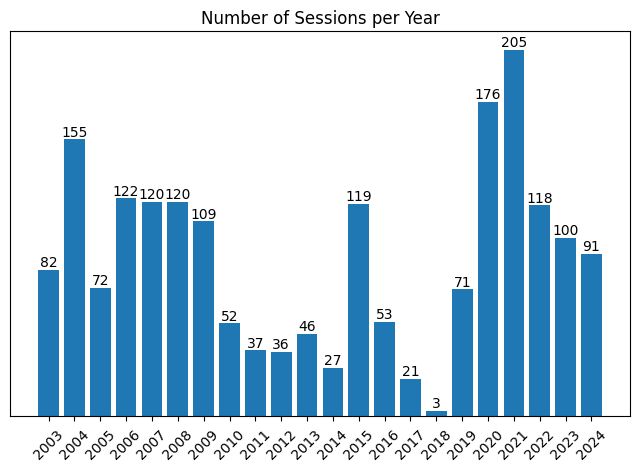

In [25]:
# -- Create figure
plt.figure(figsize=(8, 5))

# -- Plot the bars (ensure 'align=center' so the ticks line up nicely)
plt.bar(year_counts['year'], year_counts['count'], align='center')

# -- Place labels above bars as integers
for idx, row in year_counts.iterrows():
    plt.text(
        x=row['year'],
        y=row['count'] + 2.0,
        s=f"{int(row['count'])}",  # Ensure integer format
        ha='center'
    )

# -- Make a sorted list of the distinct years for tick placement
sorted_years = sorted(year_counts['year'].unique())

# -- Set x-ticks to integer years only and rotate by 45 degrees
plt.xticks(sorted_years, [str(int(y)) for y in sorted_years], rotation=45)

# -- Hide the y-axis and grid
plt.gca().axes.get_yaxis().set_visible(False)
plt.grid(False)

plt.title("Number of Sessions per Year")
plt.show()

In [26]:
df_sessions_author

,id,descricao,aprovacao,data,ultimaApresentacaoProposicao_idProposicao,ultimaApresentacaoProposicao_descricao,Type,E_Number,PL_number,PL_year,materia,author,year
0,102569-61,"Aprovada a Emenda de Redação de Srs. Líderes, ...",1.0,2003-03-18,106259,"Leitura do Parecer pelo Relator, Dep. Gervásio...",Emenda,11,79,2002,49877,Luiz Otavio,2003
1,105505-23,Rejeitadas as Emendas de nºs 1 a 5 apresentada...,0.0,2003-04-01,109185,"Parecer Proferido em Plenário, Dep. Laura Carn...",Emenda,1,105,2003,56283,Ana Júlia Carepa,2003
2,14312-64,"Rejeitadas em globo as Emendas de nºs. 1, 2, 3...",0.0,2003-04-02,0,"Apresentação do Requerimento, REQ 15, pelo Dep...",Emenda,1,53,1999,1199,Mozarildo Cavalcanti,2003
3,14312-65,Aprovada a Proposta de Emenda à Constituição n...,1.0,2003-04-02,0,"Apresentação do Requerimento, REQ 15, pelo Dep...",Emenda,53,53,1999,1199,Mozarildo Cavalcanti,2003
4,105485-40,"Rejeitada a Emenda nº 1, apresentada na Comiss...",0.0,2003-04-09,110540,"Parecer Proferido em Plenário, Dep. Ney Lopes,...",Emenda,1,91,2002,49991,Ari Stadler,2003
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1930,2269745-144,Aprovadas as Emendas do Senado Federal ao Proj...,1.0,2024-12-18,2481147,Parecer às Emendas do Senado Federal proferido...,Emenda,327,327,2021,162766,Câmara dos Deputados,2024
1931,2269745-146,Rejeitados a Emenda do Senado Federal nº 3; o ...,0.0,2024-12-18,2481147,Parecer às Emendas do Senado Federal proferido...,Emenda,3,327,2021,162766,Irajá,2024
1932,347421-200,"Aprovada, em primeiro turno, a Emenda Aglutina...",1.0,2024-12-19,2025915,Apresentação do Requerimento de Inclusão na Or...,Emenda,31,31,2007,79938,Cristovam Buarque,2024
1933,347421-221,"Aprovada, em segundo turno, a Proposta de Emen...",1.0,2024-12-19,2025915,Apresentação do Requerimento de Inclusão na Or...,Emenda,31,31,2007,79938,Cristovam Buarque,2024


In [28]:
df_sessions_author.to_csv('df_sessions_author.csv', index=False, encoding='utf-8')